# Analisi copy number Wakhan per gene

Parsing dei VCF di segmenti CNA prodotti da Wakhan e controllo dello stato del copy number
per una lista di geni (default: pannello GBM in `wakhan_utils.DEFAULT_GENE_BED`).

In [5]:
from wakhan_utils import (
    DEFAULT_GENE_BED,
    annotate_genes_cn,
    annotate_genes_cn_multi,
    plot_gene_cn_heatmap,
    load_gene_regions,
)

## Parametri

Cambia `sample` per rieseguire l'analisi su un'altra linea cellulare: tutte le linee
sono nella stessa cartella `base_dir`, e il path del VCF (il cui nome include stime di
purezza/ploidia variabili per campione, es. `Sample_3.44_0.87_0.91_...`) viene trovato
automaticamente dentro `solution_1/vcf_output/`.

In [29]:
import glob

base_dir = "/CTGlab/projects/GBM/seqperglio/lumos/wakhan"
sample = "RG1"  # cambia qui per analizzare un'altra linea cellulare
solution = "solution_1"

vcf_dir = f"{base_dir}/{sample}/wakhan_cna/{solution}/vcf_output"
integers_vcf = glob.glob(f"{vcf_dir}/*_wakhan_cna_integers.vcf")[0]
subclonals_vcf = glob.glob(f"{vcf_dir}/*_wakhan_cna_subclonals.vcf")[0]

output_dir = f"{base_dir}/check4rtpcr"
integers_vcf, subclonals_vcf

('/CTGlab/projects/GBM/seqperglio/lumos/wakhan/RG1/wakhan_cna/solution_1/vcf_output/Sample_2.02_0.97_0.99_wakhan_cna_integers.vcf',
 '/CTGlab/projects/GBM/seqperglio/lumos/wakhan/RG1/wakhan_cna/solution_1/vcf_output/Sample_2.02_0.97_0.99_wakhan_cna_subclonals.vcf')

## Gene list (BED)

Percorso del BED dei geni da controllare (default: pannello GBM in `wakhan_utils.DEFAULT_GENE_BED`).
Cambia `gene_bed` qui sotto per usare un pannello diverso in tutto il notebook.

In [24]:
gene_bed = DEFAULT_GENE_BED  # cambia qui il path per usare un BED custom (chr, start, end, gene)

gene_bed = "/CTGlab/db/biorad_centromeric_copy-number-reference_assays_2026.genecode.v48.bed"

load_gene_regions(gene_bed)

,chr,start,end,gene
0,chr1,119368778,119394130,HAO2
1,chr1,119911552,120100779,NOTCH2
2,chr1,145719470,145739288,CD160
3,chr10,37125597,37232567,ANKRD30A
4,chr11,47572196,47578976,KBTBD4
5,chr11,47617314,47642607,MTCH2
6,chr12,33374237,33439819,SYT10
7,chr12,39293227,39443390,KIF21A
8,chr12,43758943,43798307,IRAK4
9,chr13,19958676,20091829,ZMYM2


## Geni annotati con singolo vcf (integers di wakhan)

In [30]:
output_path = f"{output_dir}/{sample}_rtpcr_gene_cna.tsv"
missing_genes_path = f"{output_dir}/{sample}_rtpcr_missing_genes.tsv"

ann = annotate_genes_cn(
    integers_vcf,
    gene_bed=gene_bed,
    sample=sample,
    output_path=output_path,
    missing_genes_output_path=missing_genes_path,
)
ann[["sample", "gene", "chr", "start", "end", "seg_type", "cna", "alt", "tcn", "cn1", "cn2", "overlap_bp"]]

No CNA segment overlaps (RG1): HAO2, ANKRD30A, KBTBD4, MTCH2, SYT10, KIF21A, IRAK4, ZMYM2, GJA3, TTC5, NIPA1, NIPA2, ITGAD, ZNF843, ORC6, MYLK3, TMEM11, ANKRD30B, PLEKHF1, URI1, THNSL2, MRPS5, ENTPD6, GINS1, ID1, SUN5, RBM11, SAMSN1, EPHA3, ARL13B, NSUN3, SLAIN2, FRYL, DCUN1D4, SPATA18, HCN1, ITGA2, DST, KHDRBS2, ANK1, RNF170, CEBPD, USP9Y


,sample,gene,chr,start,end,seg_type,cna,alt,tcn,cn1,cn2,overlap_bp
0,RG1,NOTCH2,chr1,120000000,151000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,100779
1,RG1,CD160,chr1,120000000,151000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,19818
2,RG1,WSB1,chr17,22000000,28000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,21851
3,RG1,GREB1L,chr18,15000000,22000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,283881
4,RG1,IL17RA,chr22,-1,19000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,30740
5,RG1,PARP8,chr5,46000000,52000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,180621
6,RG1,VOPP1,chr7,55294376,58000000,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",<DUP>,3.0,2.0,1.0,136933
7,RG1,ASL,chr7,63000000,77686088,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",<DUP>,3.0,2.0,1.0,18898
8,RG1,CRCP,chr7,63000000,77686088,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",<DUP>,3.0,2.0,1.0,39965
9,RG1,ALDH1B1,chr9,38000000,65000000,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",<DEL>,1.0,1.0,0.0,5960


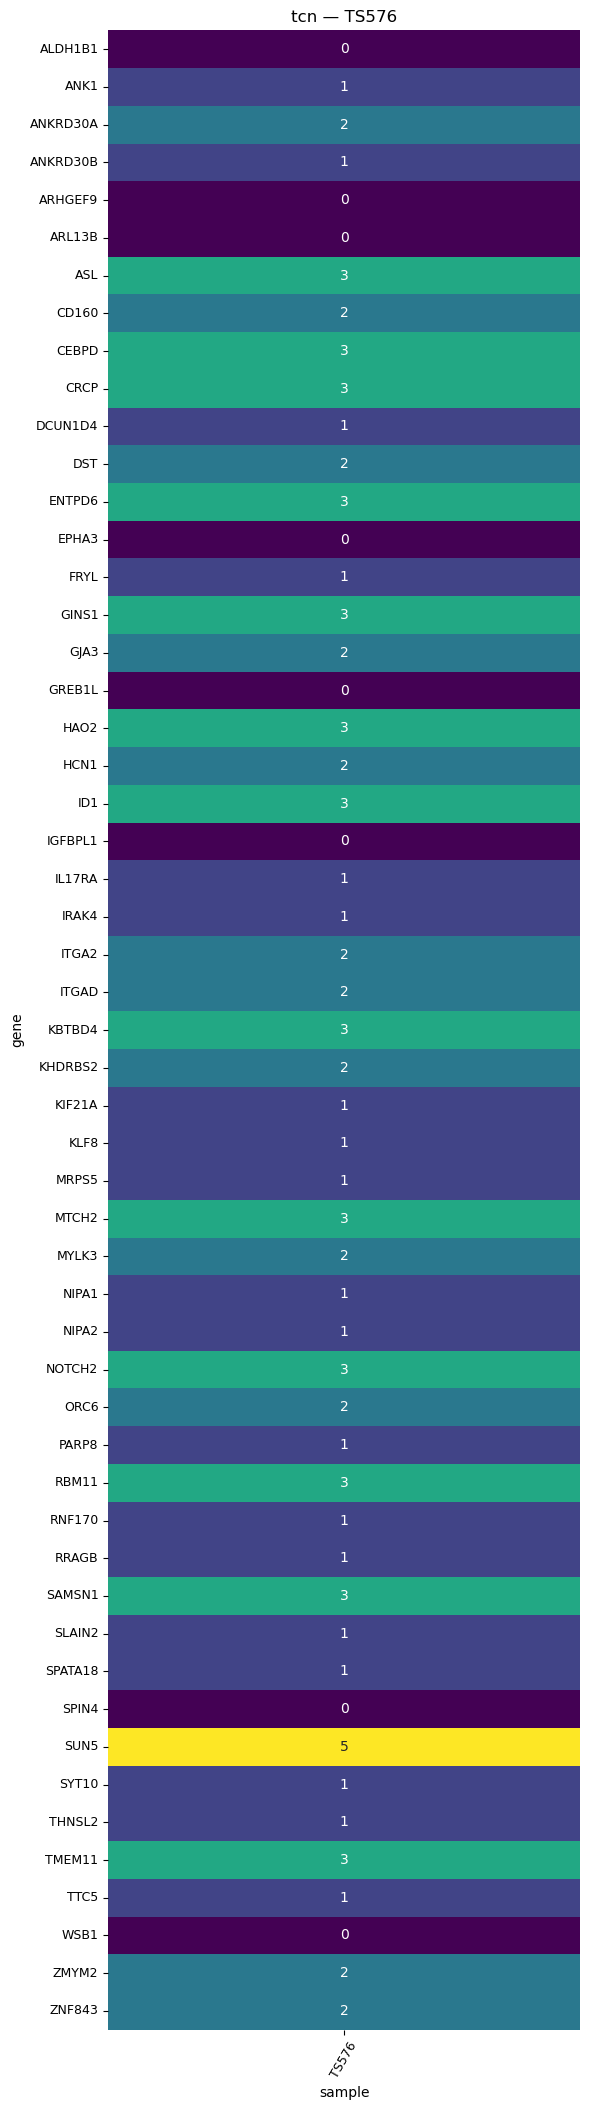

In [26]:
plot_gene_cn_heatmap(ann, value="tcn")

## Geni annotati con CNA integers and subclonals



In [31]:
vcf_paths = {
    f"{solution}.integers": integers_vcf,
    f"{solution}.subclonals": subclonals_vcf,
}
multi_output_path = f"{output_dir}/{sample}_rtpcr_gene_cna.tsv"
multi_missing_genes_path = f"{output_dir}/{sample}_rtpcr_missing_genes.tsv"

df = annotate_genes_cn_multi(
    vcf_paths,
    gene_bed=gene_bed,
    output_path=multi_output_path,
    missing_genes_output_path=multi_missing_genes_path,
)
df[["sample", "gene", "seg_type", "cna", "tcn", "cn1", "cn2"]]

No CNA segment overlaps (solution_1.integers): HAO2, ANKRD30A, KBTBD4, MTCH2, SYT10, KIF21A, IRAK4, ZMYM2, GJA3, TTC5, NIPA1, NIPA2, ITGAD, ZNF843, ORC6, MYLK3, TMEM11, ANKRD30B, PLEKHF1, URI1, THNSL2, MRPS5, ENTPD6, GINS1, ID1, SUN5, RBM11, SAMSN1, EPHA3, ARL13B, NSUN3, SLAIN2, FRYL, DCUN1D4, SPATA18, HCN1, ITGA2, DST, KHDRBS2, ANK1, RNF170, CEBPD, USP9Y
No CNA segment overlaps (solution_1.subclonals): HAO2, ANKRD30A, KBTBD4, MTCH2, KIF21A, IRAK4, ZMYM2, GJA3, TTC5, NIPA1, NIPA2, ITGAD, ZNF843, ORC6, MYLK3, TMEM11, ANKRD30B, PLEKHF1, URI1, SUN5, RBM11, SAMSN1, NSUN3, SPATA18, HCN1, ITGA2, DST, ANK1, RNF170, CEBPD, USP9Y


,sample,gene,seg_type,cna,tcn,cn1,cn2
0,solution_1.integers,NOTCH2,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
1,solution_1.integers,CD160,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
2,solution_1.integers,WSB1,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
3,solution_1.integers,GREB1L,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
4,solution_1.integers,IL17RA,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
5,solution_1.integers,PARP8,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0
6,solution_1.integers,VOPP1,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",3.0,2.0,1.0
7,solution_1.integers,ASL,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",3.0,2.0,1.0
8,solution_1.integers,CRCP,GAIN,"GAIN (TCN=3.0, CN1=2.0, CN2=1.0)",3.0,2.0,1.0
9,solution_1.integers,ALDH1B1,LOSS,"LOSS (TCN=1.0, CN1=1.0, CN2=0.0)",1.0,1.0,0.0


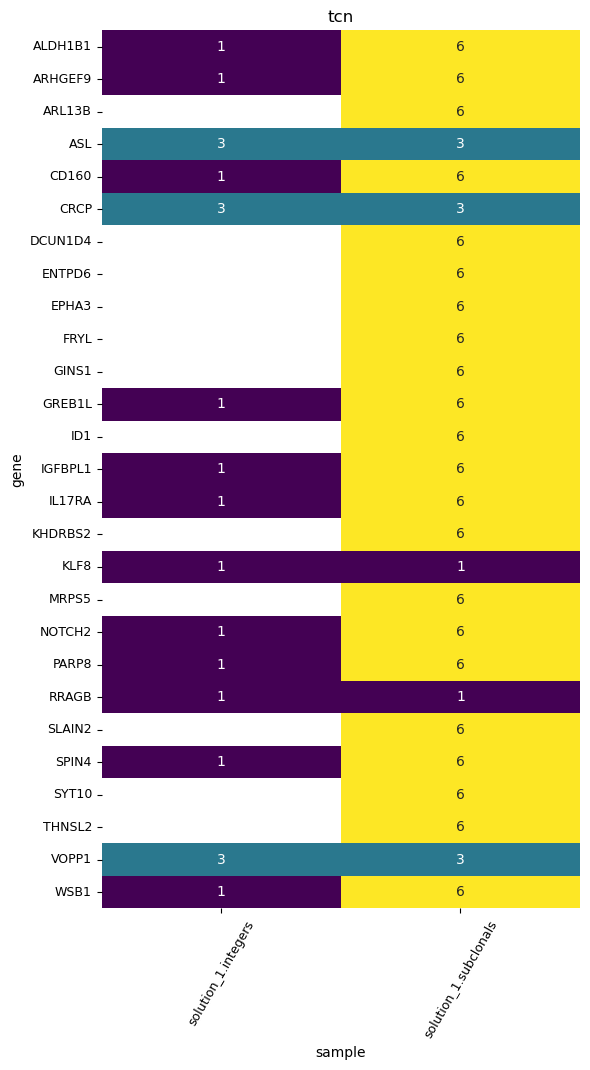

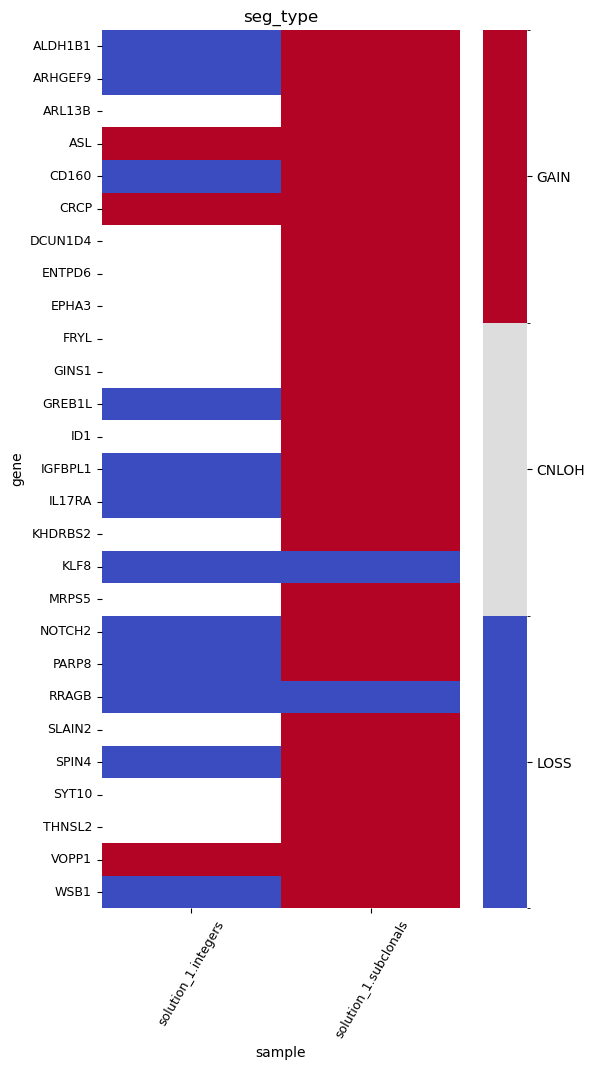

In [32]:
plot_gene_cn_heatmap(df, value="tcn", output_path=f"{output_dir}/{sample}_rtpcr_tcn.png")
plot_gene_cn_heatmap(df, value="seg_type", output_path=f"{output_dir}/{sample}_rtpcr_seg_type.png")